In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [3]:
# Load Dataset
df = pd.read_csv("diabetes (1).csv")


In [4]:
# Exploratory Data Analysis


print(df.head())

print(df.info())

print(df.describe())

# Check Missing Values
print(df.isnull().sum())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

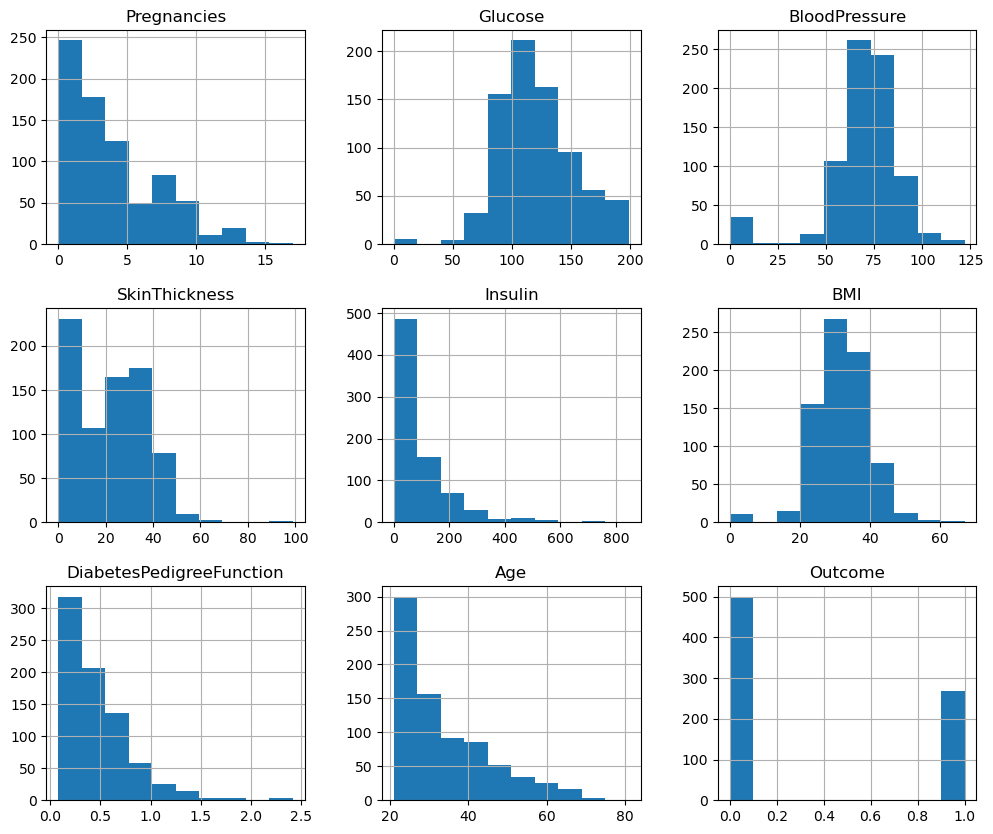

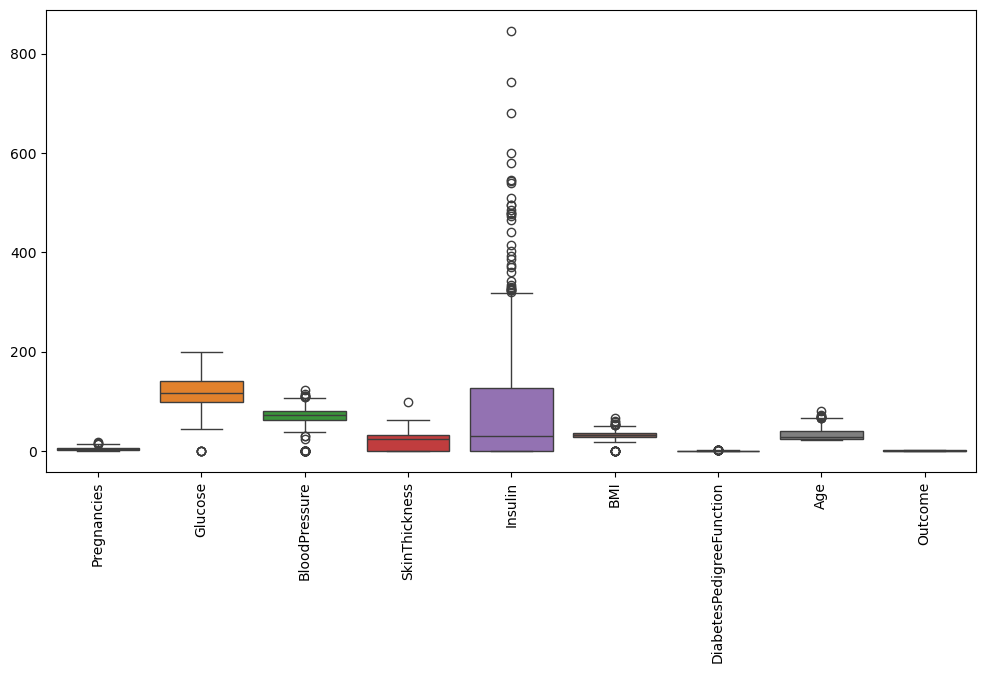

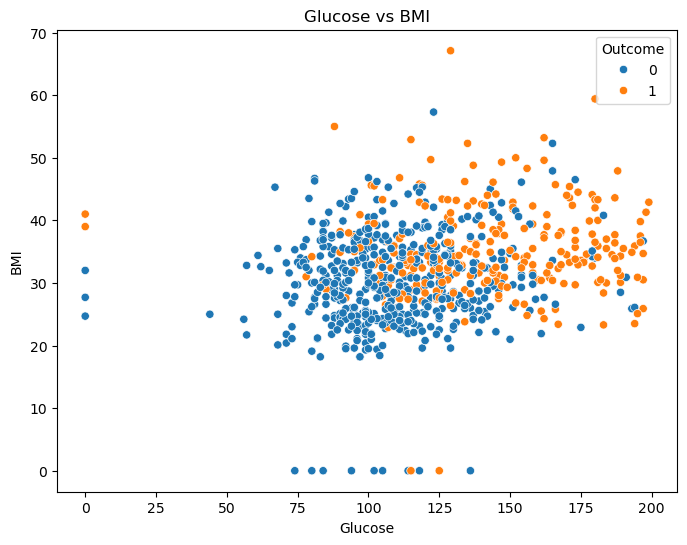

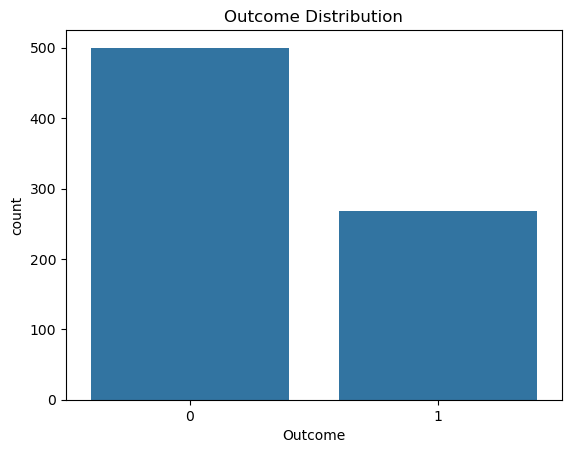

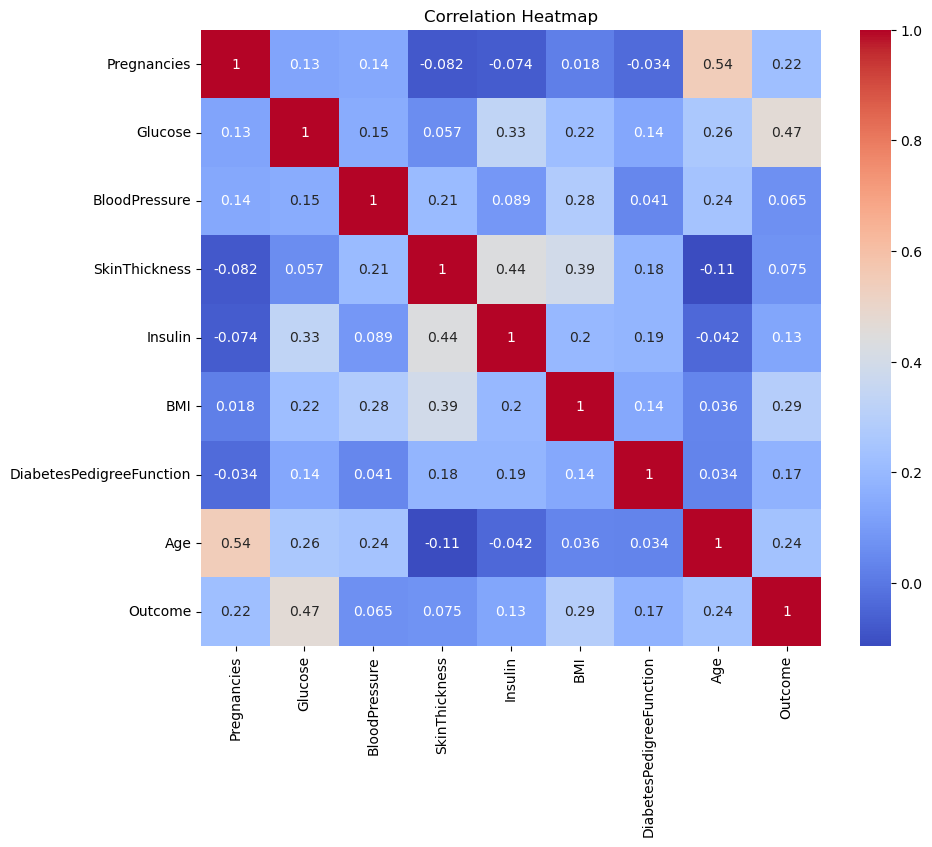

In [5]:
# Data Visualization


# Histograms
df.hist(figsize=(12,10))
plt.show()

# Boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=df
)
plt.title("Glucose vs BMI")
plt.show()

# Bar Plot
sns.countplot(x='Outcome', data=df)
plt.title("Outcome Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [7]:
# Data Preprocessing


# Replace Missing Values with Mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Features and Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
# Train Test Split

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# XGBoost Model with Hyperparameter Tuning


xgb_model = XGBClassifier(
    eval_metric='logloss'
)

xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    cv=3,
    scoring='accuracy'
)

xgb_grid.fit(x_train, y_train)

best_xgb = xgb_grid.best_estimator_

# Prediction
xgb_pred = best_xgb.predict(x_test)


In [11]:
# LightGBM Model with Hyperparameter Tuning

lgbm_model = LGBMClassifier()

lgbm_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_params,
    cv=3,
    scoring='accuracy'
)

lgbm_grid.fit(x_train, y_train)

best_lgbm = lgbm_grid.best_estimator_

# Prediction
lgbm_pred = best_lgbm.predict(x_test)



[LightGBM] [Info] Number of positive: 142, number of negative: 267
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 515
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347188 -> initscore=-0.631422
[LightGBM] [Info] Start training from score -0.631422
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [12]:
# Performance Comparison
# =====================================================

results = pd.DataFrame({

    'Model': ['XGBoost', 'LightGBM'],

    'Accuracy': [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgbm_pred)
    ],

    'Precision': [
        precision_score(y_test, xgb_pred),
        precision_score(y_test, lgbm_pred)
    ],

    'Recall': [
        recall_score(y_test, xgb_pred),
        recall_score(y_test, lgbm_pred)
    ],

    'F1 Score': [
        f1_score(y_test, xgb_pred),
        f1_score(y_test, lgbm_pred)
    ]
})

print(results)


      Model  Accuracy  Precision    Recall  F1 Score
0   XGBoost  0.753247   0.654545  0.654545  0.654545
1  LightGBM  0.740260   0.631579  0.654545  0.642857


In [13]:
# Classification Reports


print("XGBoost Classification Report")
print(classification_report(y_test, xgb_pred))

print("LightGBM Classification Report")
print(classification_report(y_test, lgbm_pred))


XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

LightGBM Classification Report
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



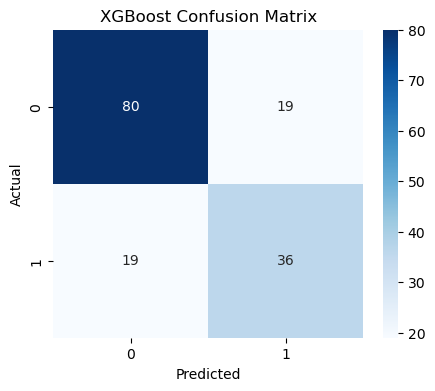

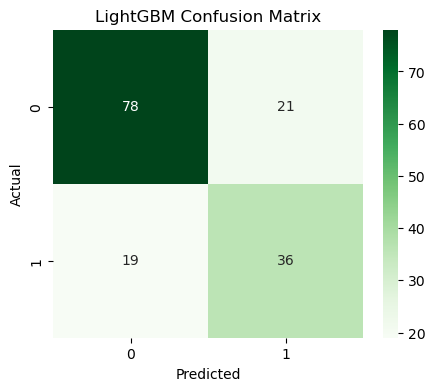

In [14]:
# Confusion Matrix
# =====================================================

# XGBoost
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# LightGBM
cm_lgbm = confusion_matrix(y_test, lgbm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Greens')

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


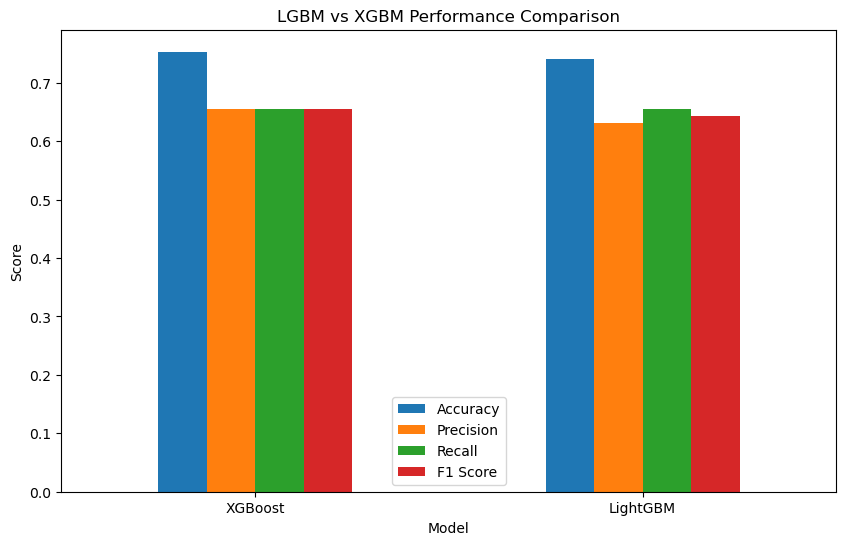

In [15]:
# Performance Visualization


results.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("LGBM vs XGBM Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()


In [16]:
# Interpretation

print("Interpretation:")
print("Both models performed well on diabetes prediction.")
print("Hyperparameter tuning improved model accuracy.")
print("The model with higher F1-score gives better balanced performance.")
print("Visualization helps compare strengths and weaknesses of both models.")

Interpretation:
Both models performed well on diabetes prediction.
Hyperparameter tuning improved model accuracy.
The model with higher F1-score gives better balanced performance.
Visualization helps compare strengths and weaknesses of both models.
